**Problem 5 Part A**

In [9]:
import numpy as np
import matplotlib.pyplot as plt

P = np.array([
    [0, 0.5, 0.5, 0, 0, 0, 0, 0],
    [0, 0, 0.5, 0.5, 0, 0, 0, 0],
    [0.5, 0, 0, 0, 0.5, 0, 0, 0],
    [1/3, 0, 1/3, 0, 1/3, 0, 0, 0],
    [0, 1/3, 0, 0, 0, 1/3, 1/3, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1, 0]
])

q_0 = np.full(8, 1/8)

def find_q_n(n):
    for i in range(n):
        p_n = np.linalg.matrix_power(P, n)
        return q_0 @ p_n

q_100 = find_q_n(100)
q_101 = find_q_n(101)

print(np.round(q_100, 6))
print(np.round(q_101, 6))


[0.       0.       0.       0.       0.       0.4375   0.267736 0.294763]
[0.       0.       0.       0.       0.       0.4375   0.294763 0.267736]


**Problem 3b**

In [ ]:
d = 0.85

G = d * P + (1 - d) * (1/8) * np.ones((8,8))

q_0 = np.full(8, 1/8)
iterations = 0
q_n = q_0

while True:
    q_n1 = q_n @ G
    iterations += 1

    if np.sum(np.abs(q_n1 - q_n)) < 10 ** -10:
        pi = q_n1
        print(f"Iterations: {iterations}")
        print(f"pi: {pi}")
        break
    
    q_n = q_n1


#Linear solve - did this in problem 1
A = G.T - np.eye(8)
A[-1, :] = 1 

right = np.zeros(8)
right[-1] = 1

pi_linsolve = np.linalg.solve(A, right)

print(f"Linear Solved Pi: {pi_linsolve}")
print(f"Matches?: {np.allclose(pi_linsolve, pi)}")





Iterations: 124
pi: [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
Linear Solved Pi: [0.07175665 0.06957763 0.09250788 0.04832049 0.07175665 0.26054035
 0.19826505 0.18727529]
Matches?: True


**Problem 3c**

Exact pi: [0.071757 0.069578 0.092508 0.04832  0.071757 0.26054  0.198265 0.187275]
Surfer 1 estimate: [0.07157 0.06939 0.0918  0.04824 0.07195 0.26677 0.19567 0.18461]
Mean estimate across surfers: [0.071835 0.069719 0.092663 0.048347 0.071835 0.261536 0.197519 0.186546]
Fitted slope: -0.4768
RMS maximum error at T = 100000: 0.005368
Independent page 6 benchmark: 0.001388
Error / benchmark: 3.867


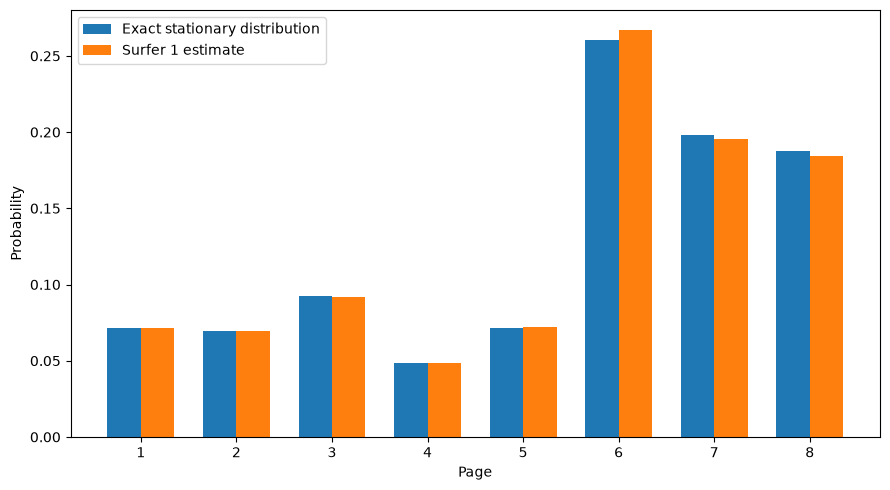

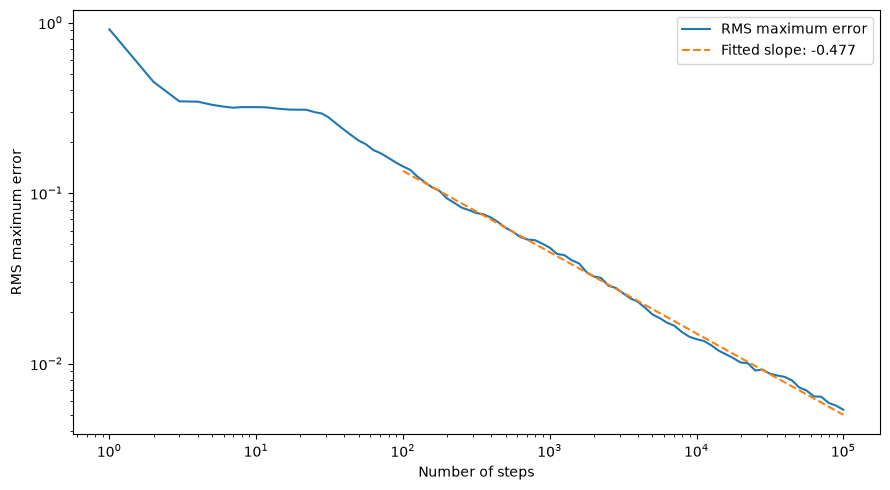

In [ ]:
R = 100
T = 10**5
rng = np.random.default_rng(34)

current = np.zeros(R, dtype=int)
count = np.zeros((R, 8), dtype=int)

checkpoints = np.unique(np.logspace(0, 5, 101).astype(int))
checkpoint_set = set(checkpoints)
rms_errors = []

for step in range(1, T + 1):
    u = rng.random(R)
    probs = G[current]

    cumulative = np.zeros(R)
    next_pages = np.full(R, 7, dtype=int)
    selected = np.zeros(R, dtype=bool)

    for page in range(8):
        cumulative += probs[:, page]
        choose = (~selected) & (u < cumulative)
        next_pages[choose] = page
        selected[choose] = True

    current = next_pages
    count[np.arange(R), current] += 1

    if step in checkpoint_set:
        estimates = count / step
        max_errors = np.max(np.abs(estimates - pi), axis=1)
        rms_errors.append(np.sqrt(np.mean(max_errors**2)))

pi_hat = count / T
rms_errors = np.array(rms_errors)

fit_mask = checkpoints >= 100

slope, intercept = np.polyfit(
    np.log(checkpoints[fit_mask]),
    np.log(rms_errors[fit_mask]),
    1
)

fit_times = checkpoints[fit_mask]
fit_errors = np.exp(intercept) * fit_times**slope

independent_error = np.sqrt(pi[5] * (1 - pi[5]) / T)

print(f"Exact pi: {np.round(pi, 6)}")
print(f"Surfer 1 estimate: {np.round(pi_hat[0], 6)}")
print(f"Mean estimate across surfers: {np.round(pi_hat.mean(axis=0), 6)}")
print(f"Fitted slope: {slope:.4f}")
print(f"RMS maximum error at T = {T}: {rms_errors[-1]:.6f}")
print(f"Independent page 6 benchmark: {independent_error:.6f}")
print(f"Error / benchmark: {rms_errors[-1] / independent_error:.3f}")


#plot!
pages = np.arange(1, 9)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(pages - width/2, pi, width, label="Exact stationary distribution")
ax.bar(pages + width/2, pi_hat[0], width, label="Surfer 1 estimate")

ax.set_xlabel("Page")
ax.set_ylabel("Probability")
ax.set_xticks(pages)
ax.legend()

fig.tight_layout()
fig.savefig("HW5_P3c_bar.png", dpi=300, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(9, 5))

ax.loglog(checkpoints, rms_errors, label="RMS maximum error")
ax.loglog(
    fit_times,
    fit_errors,
    "--",
    label=f"Fitted slope: {slope:.3f}"
)

ax.set_xlabel("Number of steps")
ax.set_ylabel("RMS maximum error")
ax.legend()

fig.tight_layout()
fig.savefig("HW5_P3c_error.png", dpi=300, bbox_inches="tight")
plt.show()